# 10. 의약품 낱알식별 정보 EDA (T0-1)

**데이터 출처**: data.go.kr OpenAPI  
**파이프라인 역할**: Stage 1 비전 온톨로지 + 전체 데이터셋 join key

## EDA 체크리스트
- [ ] 총 품목 수, 스키마 확인
- [ ] 형태·색상·각인 어휘 분포
- [ ] 이미지 URL 존재율
- [ ] 결측률 (주요 컬럼)
- [ ] e약은요(T0-2)와 품목일련번호 join 히트율 (10_nadal 완료 후 체크)
- [ ] 산출물: `data/interim/nadal_ident_clean.parquet` + `nadal_ident_summary.json`

In [1]:
import os, json, time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
from pathlib import Path
from tqdm import tqdm

try:
    from dotenv import load_dotenv
    load_dotenv(Path("../../.env").resolve())
except ImportError:
    pass

ROOT = Path("../../").resolve()
RAW = ROOT / "data" / "raw" / "nadal_ident"
INTERIM = ROOT / "data" / "interim"
RAW.mkdir(parents=True, exist_ok=True)

DATAGOKR_KEY = os.environ.get("DATAGOKR_NADAL_KEY", "")
API_URL = "http://apis.data.go.kr/1471000/MdcinGrnIdntfcInfoService03/getMdcinGrnIdntfcInfoList03"

In [2]:
def fetch_page(page, rows=100):
    params = {
        "serviceKey": DATAGOKR_KEY,
        "pageNo": page,
        "numOfRows": rows,
        "type": "json"
    }
    resp = requests.get(API_URL, params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()

# 총 건수 확인
first = fetch_page(1, rows=1)
total_count = first.get("body", {}).get("totalCount", 0)
print(f"총 {total_count:,}건")

총 25,518건


In [3]:
# 전체 데이터 수집 (캐시 있으면 스킵)
cache_file = RAW / "nadal_ident_all.json"

if cache_file.exists():
    with open(cache_file, encoding="utf-8") as f:
        all_items = json.load(f)
    print(f"캐시 로드: {len(all_items):,}건")
else:
    ROWS = 100
    pages = (total_count + ROWS - 1) // ROWS
    all_items = []
    for p in tqdm(range(1, pages + 1)):
        data = fetch_page(p, rows=ROWS)
        items = data.get("body", {}).get("items", [])
        all_items.extend(items)
        time.sleep(0.1)  # API 부하 방지
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(all_items, f, ensure_ascii=False)
    print(f"수집 완료: {len(all_items):,}건")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [03:30<00:00,  1.22it/s]


수집 완료: 25,518건


In [4]:
df = pd.DataFrame(all_items)
print(f"shape: {df.shape}")
print("\n컬럼 목록:")
print(df.columns.tolist())

shape: (25518, 33)

컬럼 목록:
['ITEM_SEQ', 'ITEM_NAME', 'ENTP_SEQ', 'ENTP_NAME', 'CHART', 'ITEM_IMAGE', 'PRINT_FRONT', 'PRINT_BACK', 'DRUG_SHAPE', 'COLOR_CLASS1', 'COLOR_CLASS2', 'LINE_FRONT', 'LINE_BACK', 'LENG_LONG', 'LENG_SHORT', 'THICK', 'IMG_REGIST_TS', 'CLASS_NO', 'CLASS_NAME', 'ETC_OTC_NAME', 'ITEM_PERMIT_DATE', 'FORM_CODE_NAME', 'MARK_CODE_FRONT_ANAL', 'MARK_CODE_BACK_ANAL', 'MARK_CODE_FRONT_IMG', 'MARK_CODE_BACK_IMG', 'ITEM_ENG_NAME', 'CHANGE_DATE', 'MARK_CODE_FRONT', 'MARK_CODE_BACK', 'EDI_CODE', 'BIZRNO', 'STD_CD']


In [ ]:
# 결측률
missing = (df.isna() | (df == "")).sum() / len(df) * 100
missing.sort_values(ascending=False).head(20)

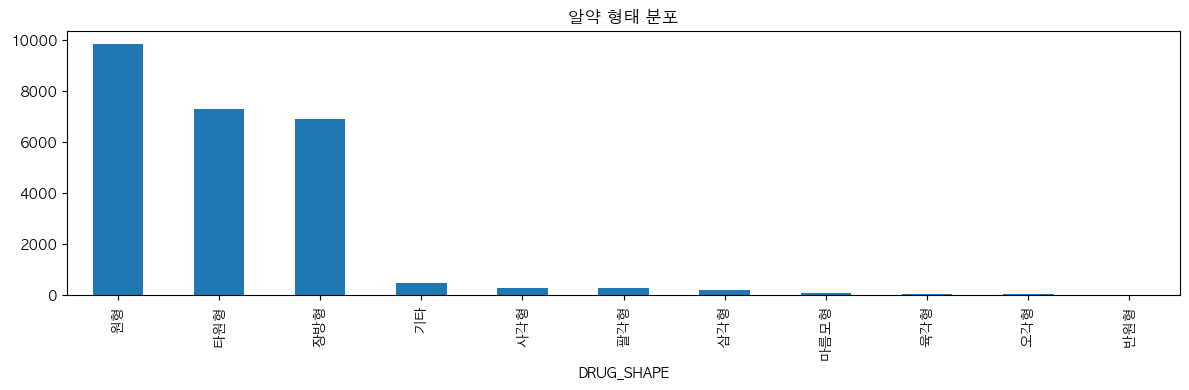

In [5]:
# 형태(DRUG_SHAPE) 분포
df["DRUG_SHAPE"].value_counts().plot(kind="bar", figsize=(12, 4), title="알약 형태 분포")
plt.tight_layout()
plt.show()

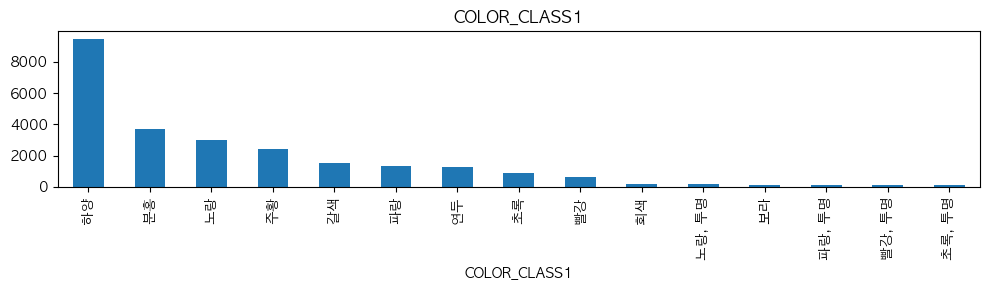

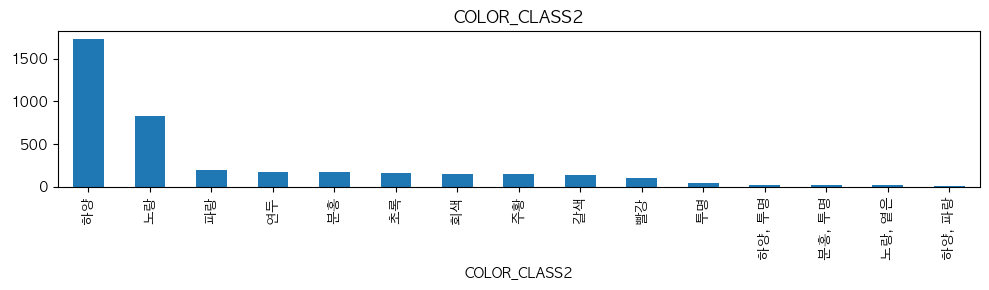

In [6]:
# 색상(COLOR_CLASS1, COLOR_CLASS2) 분포
for col in ["COLOR_CLASS1", "COLOR_CLASS2"]:
    if col in df.columns:
        df[col].value_counts().head(15).plot(kind="bar", figsize=(10, 3), title=col)
        plt.tight_layout()
        plt.show()

PRINT_FRONT 존재율: 98.8%


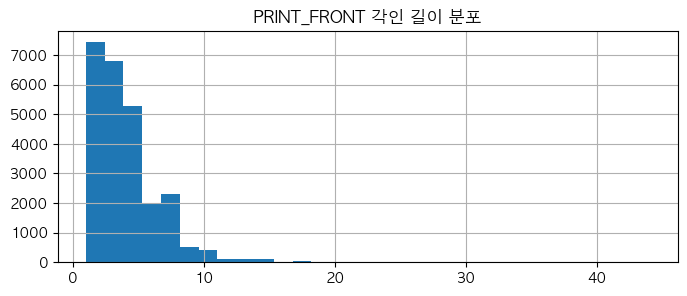

PRINT_BACK 존재율: 49.4%


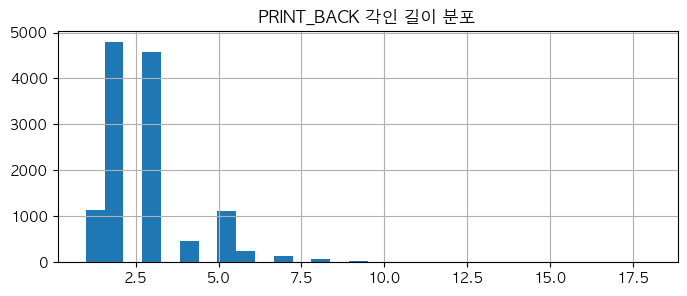

In [7]:
# 각인(PRINT_FRONT / PRINT_BACK) 존재율 및 길이 분포
for col in ["PRINT_FRONT", "PRINT_BACK"]:
    if col in df.columns:
        has_imprint = df[col].notna() & (df[col] != "")
        print(f"{col} 존재율: {has_imprint.mean():.1%}")
        df.loc[has_imprint, col].str.len().hist(bins=30, figsize=(8, 3))
        plt.title(f"{col} 각인 길이 분포")
        plt.show()

In [8]:
# 이미지 URL 존재율
if "ITEM_IMAGE" in df.columns:
    img_rate = (df["ITEM_IMAGE"].notna() & (df["ITEM_IMAGE"] != "")).mean()
    print(f"이미지 URL 존재율: {img_rate:.1%}")

이미지 URL 존재율: 100.0%


In [9]:
# 품목일련번호 유일성 확인
id_col = "ITEM_SEQ"
if id_col in df.columns:
    print(f"총 행: {len(df):,} | 유일 {id_col}: {df[id_col].nunique():,}")

총 행: 25,518 | 유일 ITEM_SEQ: 25,501


In [10]:
# 인코딩 확인 (CP949 잔재 탐지)
def has_encoding_artifact(s):
    if not isinstance(s, str):
        return False
    return any(ord(c) > 0xFFFF or c in ['\ufffd'] for c in s)

artifact_cols = {}
for col in df.select_dtypes(include="object").columns:
    cnt = df[col].apply(has_encoding_artifact).sum()
    if cnt > 0:
        artifact_cols[col] = cnt
print("인코딩 이상 컬럼:", artifact_cols if artifact_cols else "없음")

인코딩 이상 컬럼: 없음


In [11]:
# 산출물 저장
df.to_parquet(INTERIM / "nadal_ident_clean.parquet", index=False)

summary = {
    "total_rows": len(df),
    "columns": df.columns.tolist(),
    "unique_item_seq": int(df["ITEM_SEQ"].nunique()) if "ITEM_SEQ" in df.columns else None,
    "image_url_rate": float((df["ITEM_IMAGE"].notna() & (df["ITEM_IMAGE"] != "")).mean()) if "ITEM_IMAGE" in df.columns else None,
    "shape_vocab_size": int(df["DRUG_SHAPE"].nunique()) if "DRUG_SHAPE" in df.columns else None,
}
with open(INTERIM / "nadal_ident_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("저장 완료")
print(json.dumps(summary, ensure_ascii=False, indent=2))

저장 완료
{
  "total_rows": 25518,
  "columns": [
    "ITEM_SEQ",
    "ITEM_NAME",
    "ENTP_SEQ",
    "ENTP_NAME",
    "CHART",
    "ITEM_IMAGE",
    "PRINT_FRONT",
    "PRINT_BACK",
    "DRUG_SHAPE",
    "COLOR_CLASS1",
    "COLOR_CLASS2",
    "LINE_FRONT",
    "LINE_BACK",
    "LENG_LONG",
    "LENG_SHORT",
    "THICK",
    "IMG_REGIST_TS",
    "CLASS_NO",
    "CLASS_NAME",
    "ETC_OTC_NAME",
    "ITEM_PERMIT_DATE",
    "FORM_CODE_NAME",
    "MARK_CODE_FRONT_ANAL",
    "MARK_CODE_BACK_ANAL",
    "MARK_CODE_FRONT_IMG",
    "MARK_CODE_BACK_IMG",
    "ITEM_ENG_NAME",
    "CHANGE_DATE",
    "MARK_CODE_FRONT",
    "MARK_CODE_BACK",
    "EDI_CODE",
    "BIZRNO",
    "STD_CD"
  ],
  "unique_item_seq": 25501,
  "image_url_rate": 1.0,
  "shape_vocab_size": 11
}
